In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# 1 imports and paths
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../.."
exp_name = "exp18_swin_384_strong_MSELoss_MultipleAuxHead_AuxBCEWeightedLoss_StrongHead"
img_folder  = os.path.join(main_folder, "data", "train")
out_dir     = os.path.join(main_folder, "outputs", "extra", "exp18_aux_heads_metadata_weightedBCELoss",exp_name)
out_csv     = os.path.join(main_folder, "data", "train.csv")

os.makedirs(out_dir, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
#  generate aux-labels if not already done, load CSV, set cfg
from src.utils import build_binary_aux_cfg
import sys
sys.path.insert(0, os.path.join(main_folder))

TARGET = "Pawpularity"
df = pd.read_csv(os.path.join(main_folder, "data", "train.csv"))

# --- set cfg ---
cfg = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg["img_size"] = 384
cfg["name"]     = exp_name
cfg["loss"]     = "mse"
cfg["head_type"] = "mlp"#strong head , linear or mlp
cfg["aux_tasks"]          = []                    # no regression aux
cfg["binary_aux_tasks"]   = ["Eyes","Face","Occlusion", "Blur"]
cfg["aux_loss_weights"]   = {
    "Face":      0.1,
    "Eyes":      0.1,
    "Occlusion": 0.1,
    "Blur":      0.1,
}


cfg["binary_aux_loss_type"] = "weighted_bce"

# pos_weight  = majority_count / minority_count  -> passed to BCEWithLogitsLoss to
#               up-weight the rare class during training.
# flip_targets = tasks where class 0 is the minority; labels are flipped to 1
#               so BCE always treats the minority as the positive class.because PyTorch's pos_weight only applies
#               to label=1 samples  without flipping it would have no effect on
#               the minority class when it is label 0
pos_weight_dict, flip_targets_list = build_binary_aux_cfg(df, cfg["binary_aux_tasks"])
print("pos_weight_dict:", pos_weight_dict, "flip_targets_list:", flip_targets_list)
cfg["binary_aux_pos_weight"]   = pos_weight_dict
cfg["binary_aux_flip_targets"] = flip_targets_list

cfg["use_saliency"]       = False

save_config(cfg, out_dir)
set_seed(cfg["seed"])



  Eyes: class_0=2254, class_1=7658   minority=class_0, flip target, pos_weight=3.40
  Face: class_0=952, class_1=8960   minority=class_0, flip target, pos_weight=9.41
  Occlusion: class_0=8207, class_1=1705   minority=class_1, pos_weight=4.81
  Blur: class_0=9214, class_1=698   minority=class_1, pos_weight=13.20
pos_weight_dict: {'Eyes': np.float64(3.3975155279503104), 'Face': np.float64(9.411764705882353), 'Occlusion': np.float64(4.813489736070381), 'Blur': np.float64(13.200573065902578)} flip_targets_list: ['Eyes', 'Face']


In [5]:

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)
    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp18_swin_384_strong_MSELoss_MultipleAuxHead_AuxBCEWeightedLoss_StrongHead: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: PawRMSE=23.8958 TotalLoss=571.4940 | ValRMSE: 21.0432 | train_loss_Eyes: 1.0838 | train_loss_Face: 1.2850 | train_loss_Occlusion: 1.1630 | train_loss_Blur: 1.3357 | train_train_acc_Eyes: 0.4880 | train_train_acc_Face: 0.4781 | train_train_acc_Occlusion: 0.4698 | train_train_acc_Blur: 0.4895 | Eyes_val_bce: 0.6950 | Eyes_val_acc: 0.3132 | Eyes_val_f1: 0.3231 | Eyes_val_prec: 0.2056 | Eyes_val_rec: 0.7541 | Face_val_bce: 0.7142 | Face_val_acc: 0.0893 | Face_val_f1: 0.1616 | Face_val_prec: 0.0879 | Face_val_rec: 1.0000 | Occlusion_val_bce: 0.7204 | Occlusion_val_acc: 0.1669 | Occlusion_val_f1: 0.2861 | Occlusion_val_prec: 0.1669 | Occlusion_val_rec: 1.0000 | Blur_val_bce: 0.7916 | Blur_val_acc: 0.0590 | Blur_val_f1: 0.1114 | Blur_val_prec: 0.0590 | Blur_val_rec: 1.0000
Epoch 2/10 | Fold 1 | Train[MSE]: PawRMSE=20.5113 TotalLoss=421.1958 | ValRMSE: 21.0882 | train_

In [6]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.6597 (n=1983)
Fold 2 OOF RMSE: 17.9493 (n=1983)
Fold 3 OOF RMSE: 17.4106 (n=1982)
Fold 4 OOF RMSE: 17.7243 (n=1982)
Fold 5 OOF RMSE: 18.1696 (n=1982)


In [7]:
# aux-task validation metrics 



baseline_rmse_path = os.path.join(
    "../..", "outputs", "extra", "exp3_swin_384_strong_MSE_MLPHead", "fold_rmse.npy"
)
aux_rmse_path = os.path.join(out_dir, "fold_rmse.npy")

if os.path.exists(baseline_rmse_path) and os.path.exists(aux_rmse_path):
    fold_rmse_base = np.load(baseline_rmse_path)
    fold_rmse_aux  = np.load(aux_rmse_path)

    print(f"\n{'Model':<35} {'Mean':>7} {'Std':>6}  Fold RMSEs")
    print(f"{'Swin image-only (exp3)':<35} "
          f"{fold_rmse_base.mean():>7.4f} {fold_rmse_base.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_base.tolist()]}")
    print(f"{'Swin + Blur aux (exp18)':<35} "
          f"{fold_rmse_aux.mean():>7.4f} {fold_rmse_aux.std():>6.4f}  "
          f"{[round(x,4) for x in fold_rmse_aux.tolist()]}")

    


Model                                  Mean    Std  Fold RMSEs
Swin image-only (exp3)              17.7337 0.2876  [17.7702, 18.0767, 17.3341, 17.4841, 18.0031]
Swin + Blur aux (exp18)             17.7827 0.2586  [17.6597, 17.9493, 17.4106, 17.7243, 18.1696]


### Training and Validation Loss Curve

In [8]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs","extra", "exp3_swin_384_strong_MSE_MLPHead")


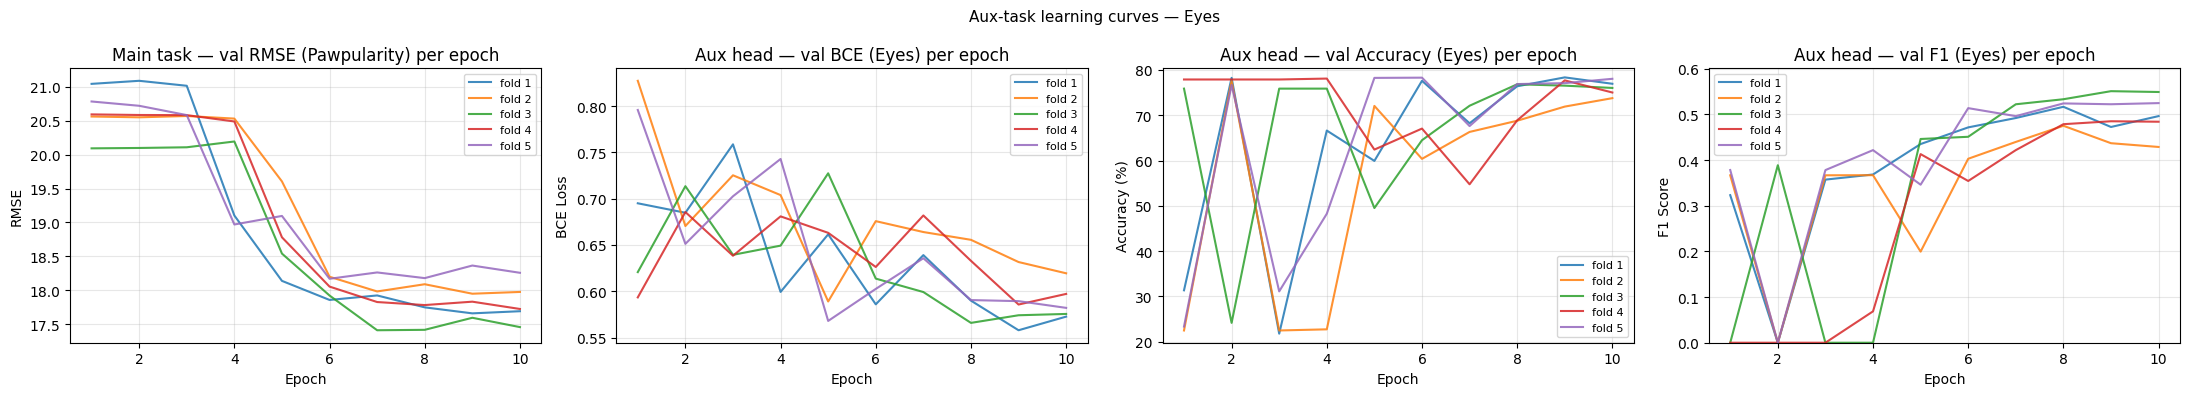

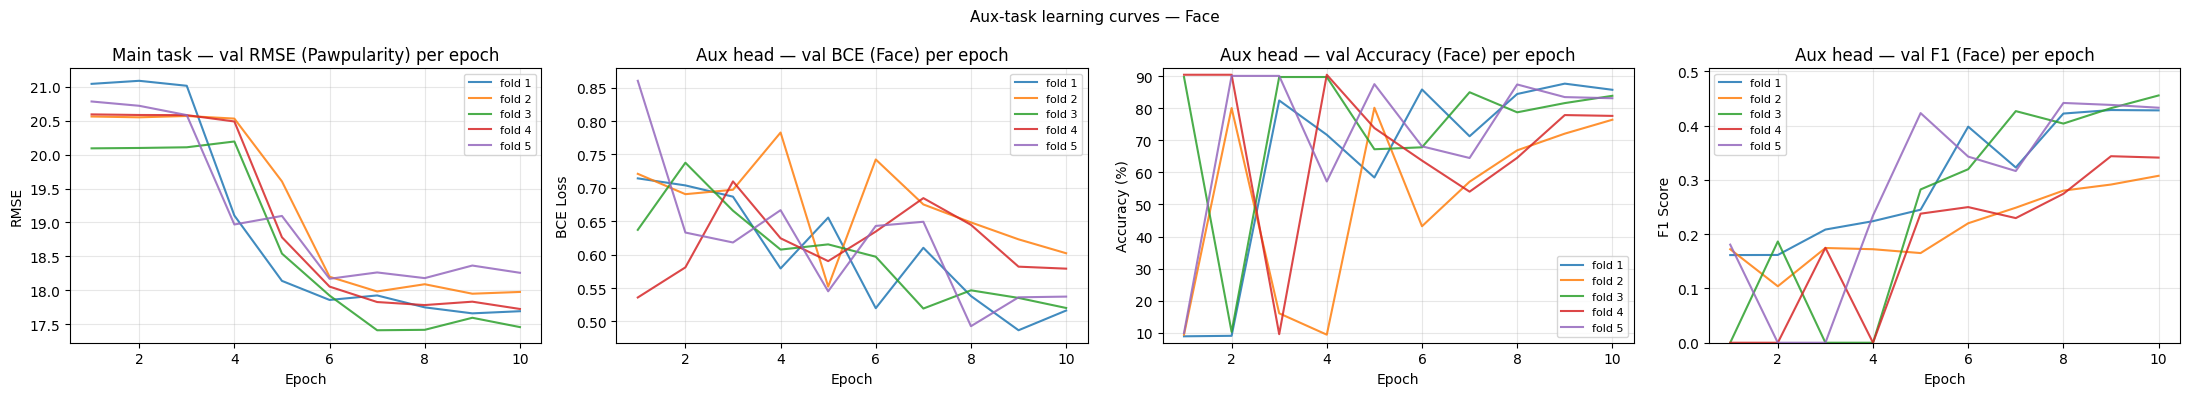

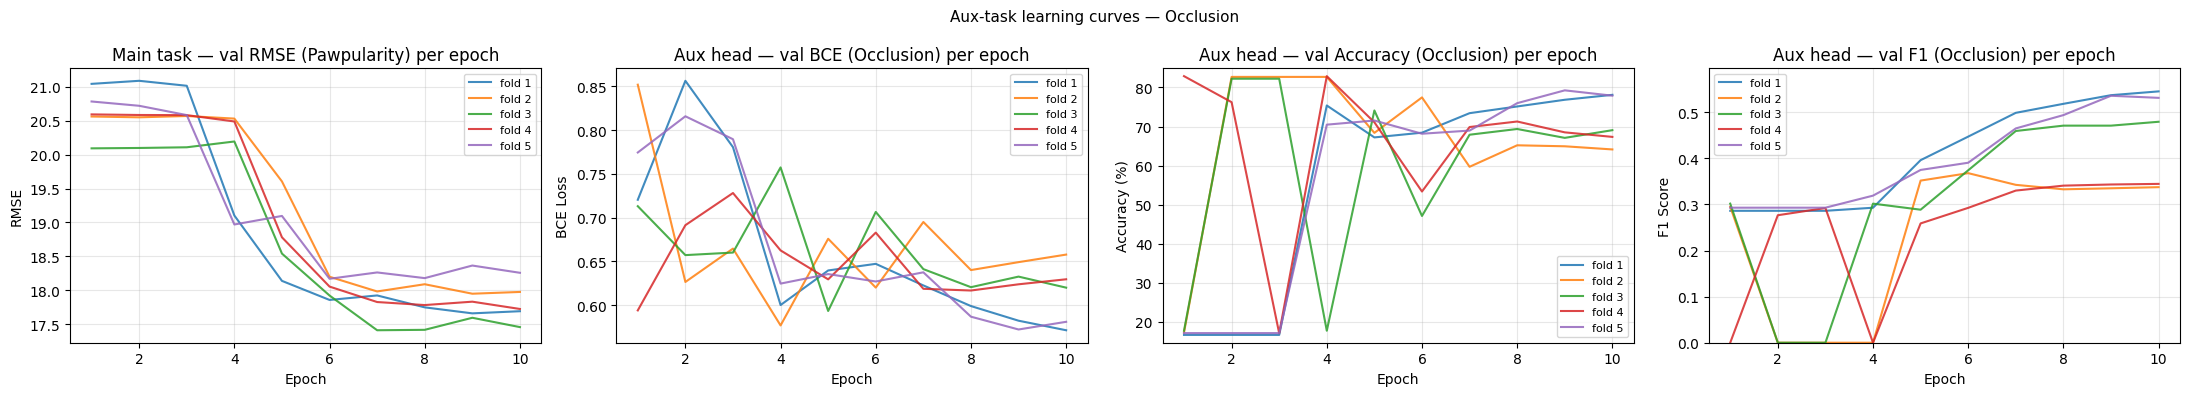

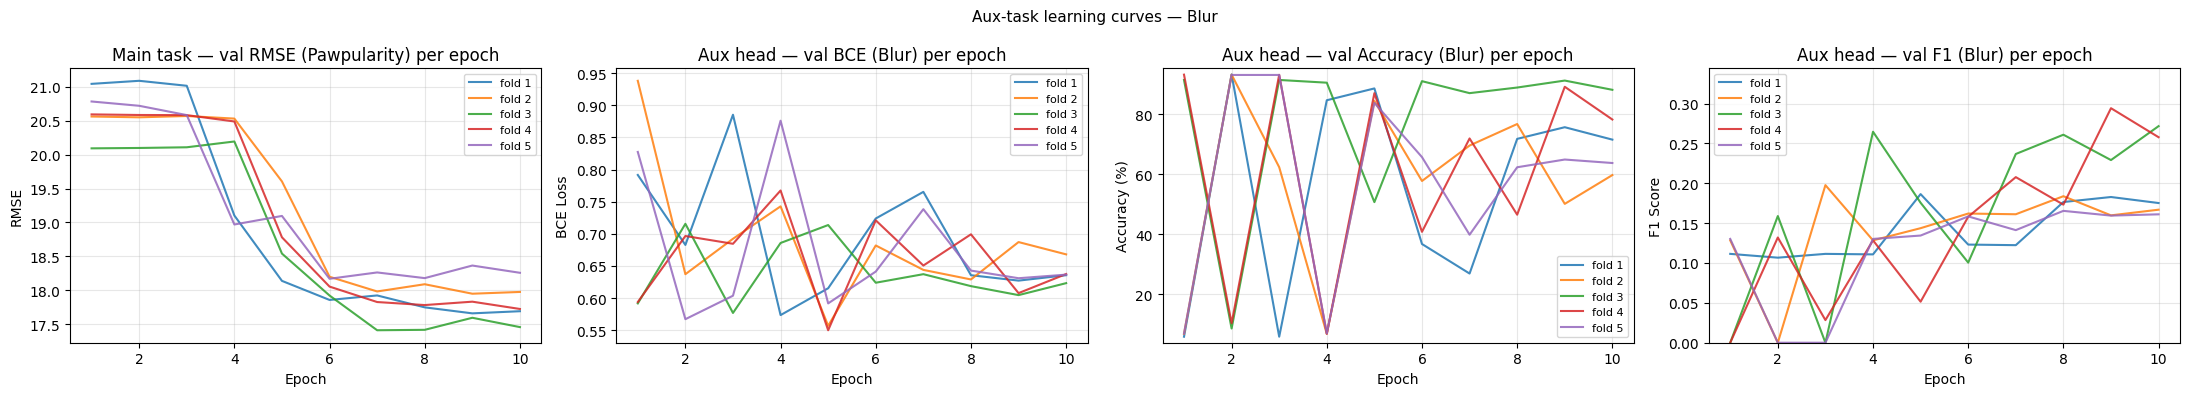

In [9]:
from src.plot import plot_metadata_aux_curves

BACKBONE = "swin_large_patch4_window12_384"
IMG_SIZE  = 384

# plot curves
plot_metadata_aux_curves(
    out_dir=out_dir,
    binary_aux_tasks=cfg["binary_aux_tasks"],
)

### Side by Side Comparison with Image only

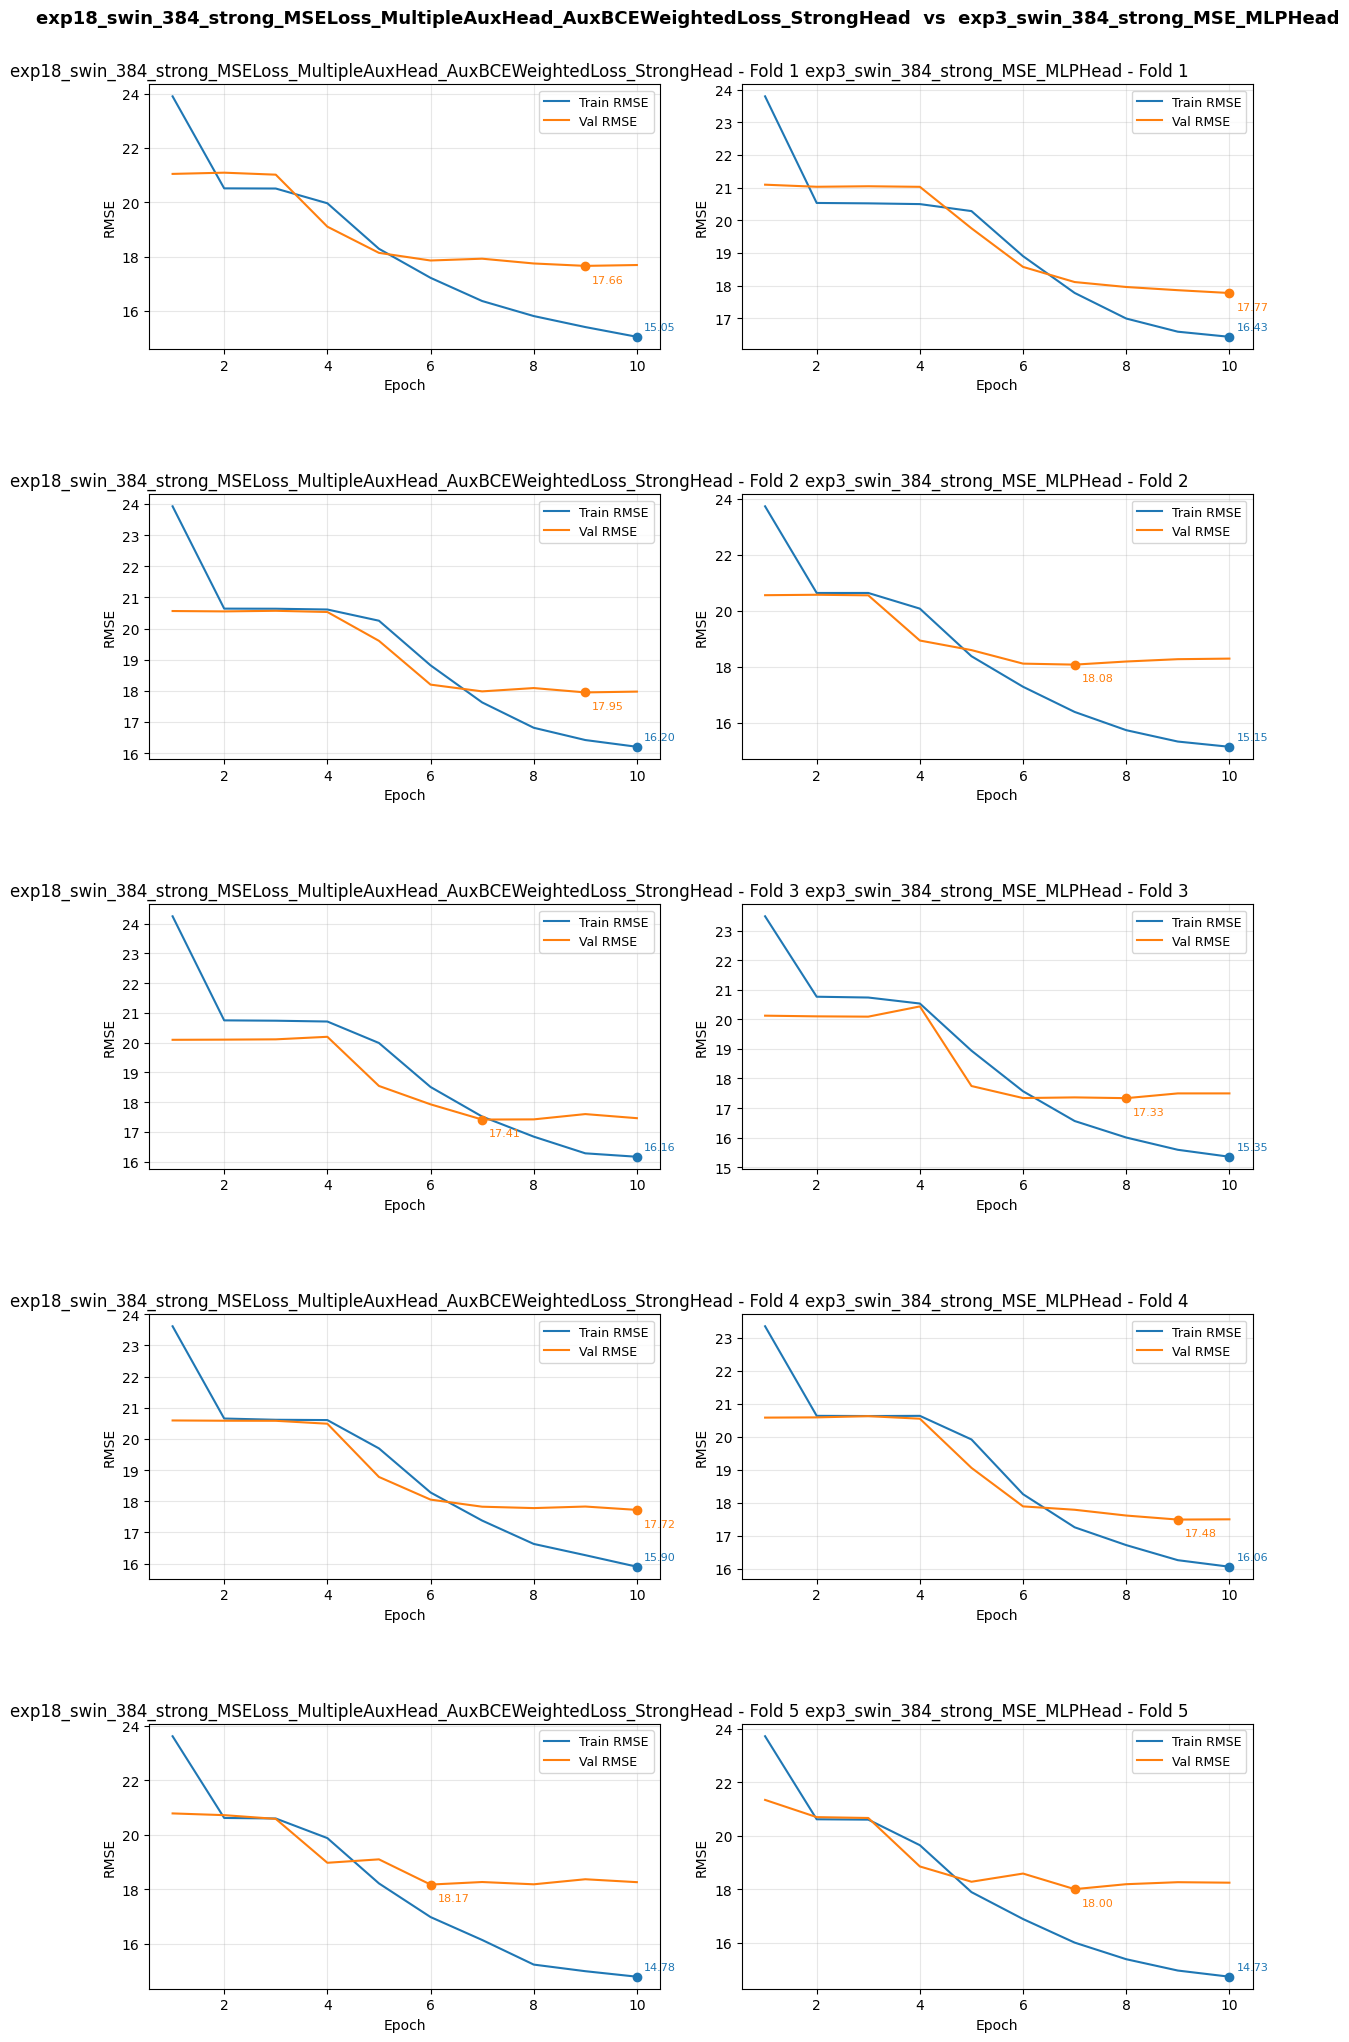

In [10]:
### Side by Side Comparison with Concatenation based Feature Fusion Exp4
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a=exp_name, label_b="exp3_swin_384_strong_MSE_MLPHead")


In [11]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,4435d6f98ad72782ca0cf61f946b016d,5,100,23.597898,76.402102
1,12b136b947a64c8b23e3929f70b41933,1,100,28.241846,71.758154
2,941e532a21f7edb21766e88a15e588cb,4,100,29.024851,70.975149
3,e5a84da44afc0abddfbb36907a5ee845,5,100,29.029783,70.970217
4,ee7d8deda7e7e353f9d7866fe8d5ef04,5,100,29.604399,70.395601


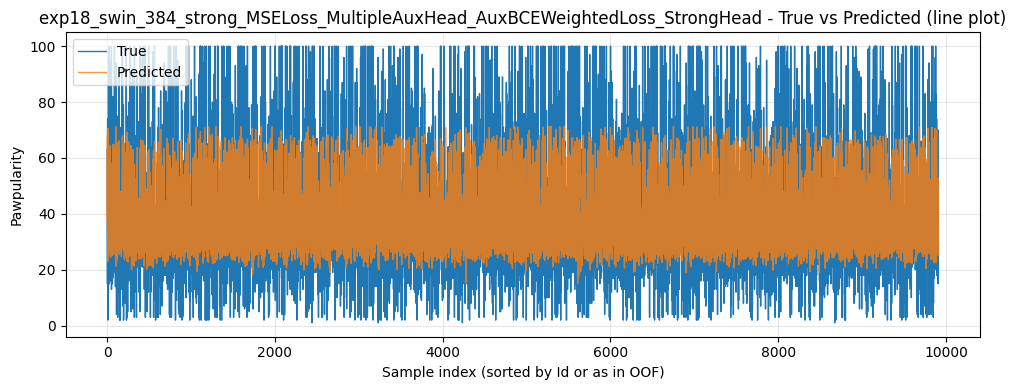

In [12]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix=exp_name)





exp18_swin_384_strong_MSELoss_MultipleAuxHead_AuxBCEWeightedLoss_StrongHead OOF RMSE: 17.78460032056869
exp3_swin_384_strong_MSE_MLPHead OOF RMSE: 17.73602090865089
ΔRMSE (exp3_swin_384_strong_MSE_MLPHead - exp18_swin_384_strong_MSELoss_MultipleAuxHead_AuxBCEWeightedLoss_StrongHead): -0.048579411917799575


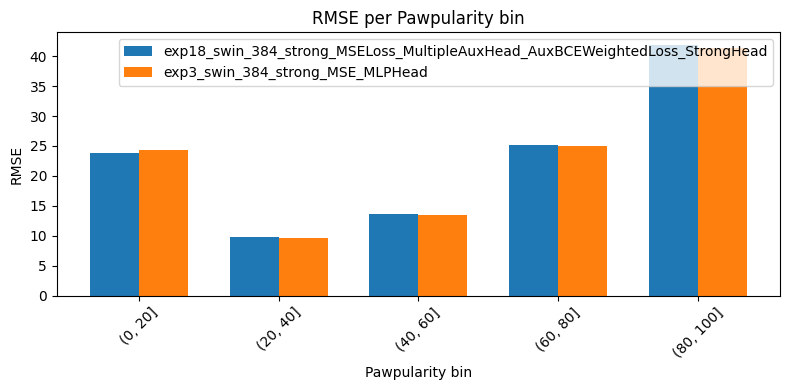

In [13]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a=exp_name,
    label_b="exp3_swin_384_strong_MSE_MLPHead",
    title_prefix="",
)

In [14]:
df_bins.head()

,bin,count,exp18_swin_384_strong_MSELoss_MultipleAuxHead_AuxBCEWeightedLoss_StrongHead_rmse,exp3_swin_384_strong_MSE_MLPHead_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.830945,24.383091,0.552146,exp18_swin_384_strong_MSELoss_MultipleAuxHead_...
1,"(20, 40]",5119,9.876286,9.719382,-0.156904,exp3_swin_384_strong_MSE_MLPHead_better
2,"(40, 60]",2088,13.631963,13.504186,-0.127777,exp3_swin_384_strong_MSE_MLPHead_better
3,"(60, 80]",727,25.136710,25.028708,-0.108002,exp3_swin_384_strong_MSE_MLPHead_better
4,"(80, 100]",561,41.873843,41.275555,-0.598288,exp3_swin_384_strong_MSE_MLPHead_better


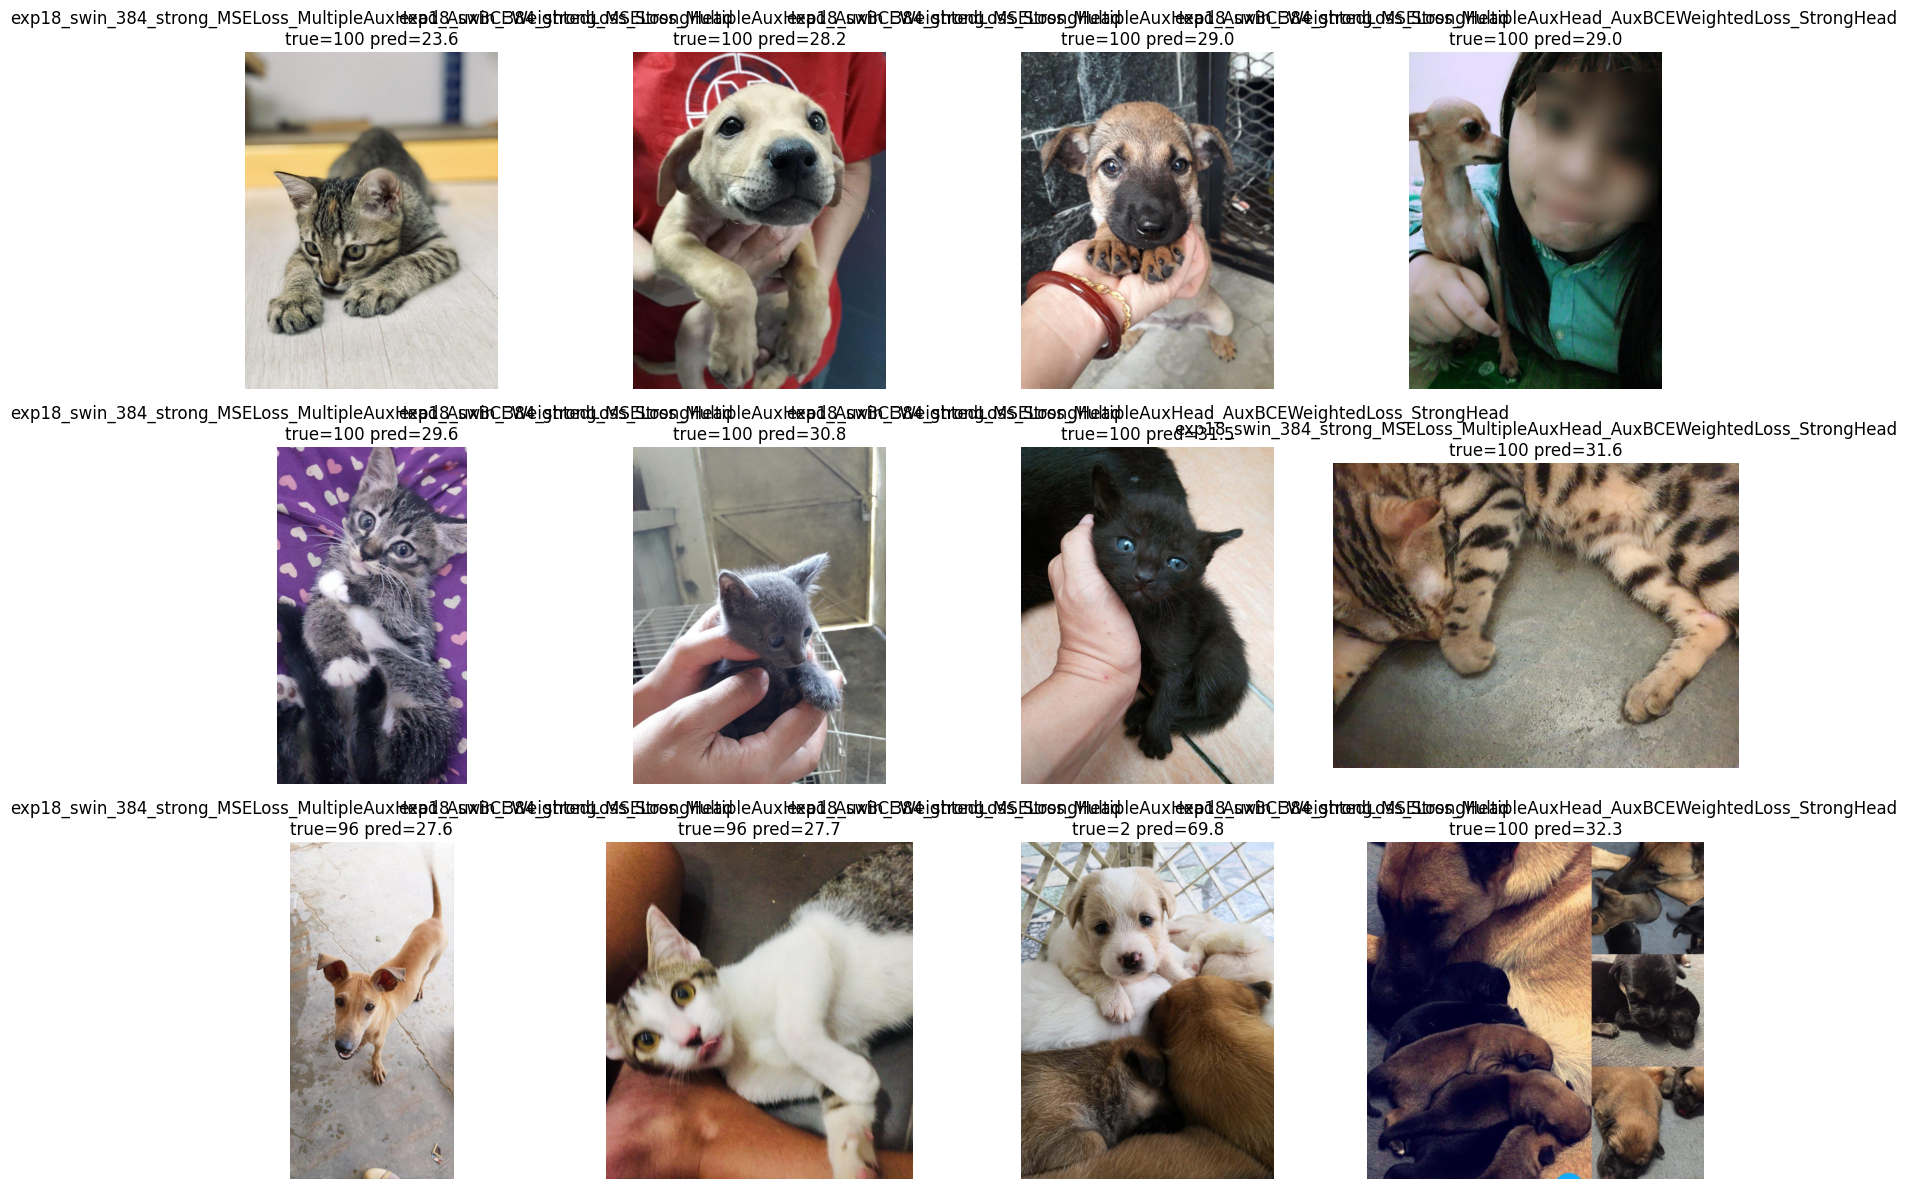

In [15]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix=exp_name)

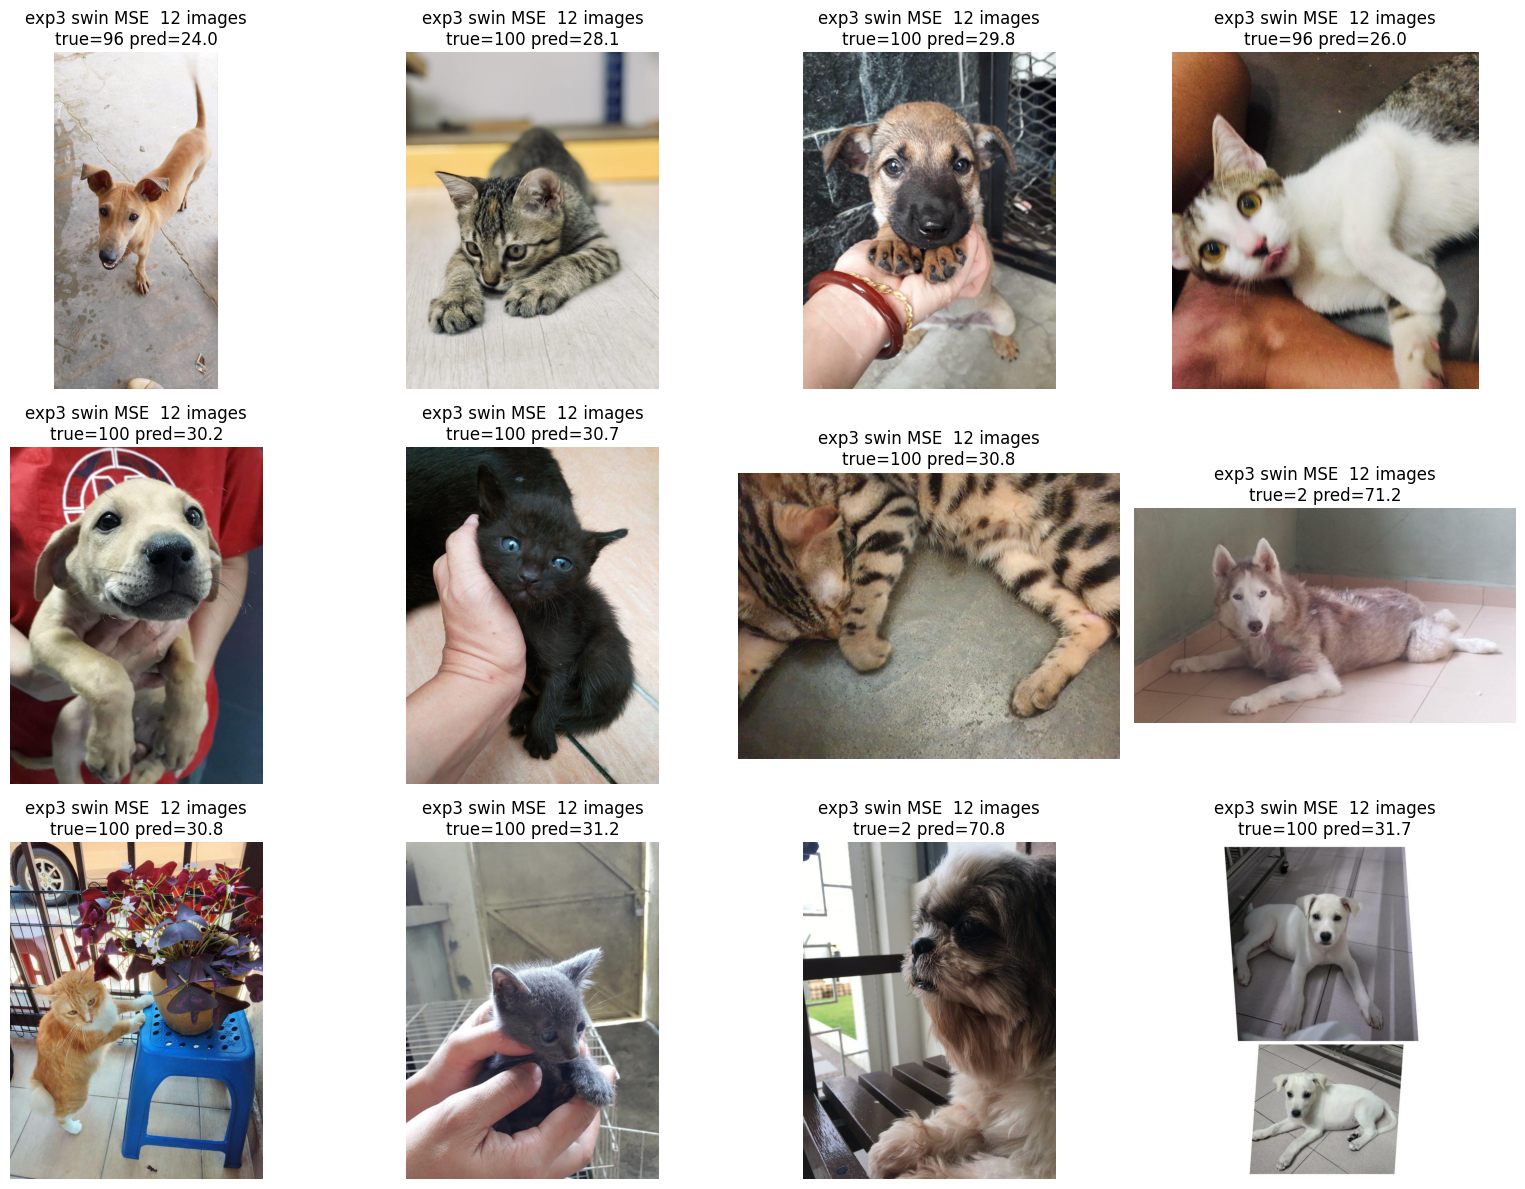

In [16]:
# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp3 swin MSE  12 images")